# Stage 1

## Libraries

In [1]:
import os
import gc
import cv2
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.models as models

try:
    from torchvision.models import EfficientNet_B3_Weights
except Exception:
    EfficientNet_B3_Weights = None

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from tqdm import tqdm

## Set up

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

CFG = {
    "HEIGHT": 256,
    "WIDTH": 1600,

    "ORIG_HEIGHT": 256,
    "ORIG_WIDTH": 1600,

    "NUM_CLASSES": 4,
    "VAL_SPLIT": 0.2,

    "BATCH_SIZE": 4,
    "NUM_WORKERS": 2,

    "EPOCHS": 100,
    "LR": 2e-4,
    "WEIGHT_DECAY": 1e-4,
    "USE_AMP": True,

    "PRETRAINED": True,
    "DROPOUT": 0.1,

    "BCE_WEIGHT": 0.7,
    "DICE_WEIGHT": 0.3,
    "DICE_SMOOTH": 1.0,

    "THRESHOLD": 0.5,
    "THRESHOLDS": [0.5, 0.5, 0.5, 0.5],

    "USE_WEIGHTED_SAMPLER": True,
}

DATA_DIR = Path("/kaggle/input/competitions/severstal-steel-defect-detection")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR  = DATA_DIR / "test_images"
WORK_DIR  = Path("/kaggle/working")

Device: cuda


## Data preprocessing

### Read csv

In [3]:
df = pd.read_csv(TRAIN_CSV)

if "ImageId_ClassId" in df.columns:
    split_cols = df["ImageId_ClassId"].str.split("_", expand=True)
    df["ImageId"] = split_cols[0]
    df["ClassId"] = split_cols[1].astype(int)

df["ClassId"] = df["ClassId"].astype(int)

print("CSV shape:", df.shape)
print("Unique images:", df["ImageId"].nunique())
print(df.head())

CSV shape: (7095, 3)
Unique images: 6666
         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
3  000f6bf48.jpg        4  131973 1 132228 4 132483 6 132738 8 132993 11 ...
4  0014fce06.jpg        3  229501 11 229741 33 229981 55 230221 77 230468...


### Metadata + weighted sample

In [4]:
def is_valid_rle_series(s):
    return (
        s.notna()
        & (s.astype(str).str.strip() != "")
        & (s.astype(str).str.lower() != "nan")
    )

all_ids = df["ImageId"].unique()
img_meta = pd.DataFrame({"ImageId": all_ids})

for c in range(1, CFG["NUM_CLASSES"] + 1):
    cls_pos = (
        df.loc[
            (df["ClassId"] == c) & is_valid_rle_series(df["EncodedPixels"]),
            "ImageId"
        ]
        .drop_duplicates()
    )
    img_meta[f"class_{c}"] = img_meta["ImageId"].isin(cls_pos).astype(int)

img_meta["any_defect"] = img_meta[[f"class_{c}" for c in range(1, 5)]].max(axis=1)
img_meta["num_defects"] = img_meta[[f"class_{c}" for c in range(1, 5)]].sum(axis=1)
img_meta["is_multi"] = (img_meta["num_defects"] > 1).astype(int)

img_meta["sample_weight"] = (
    1.0
    + 2.5 * img_meta["class_1"]
    + 5.0 * img_meta["class_2"]
    + 0.5 * img_meta["class_3"]
    + 2.0 * img_meta["class_4"]
    + 1.5 * img_meta["is_multi"]
)

print("\nClass image counts:")
print(img_meta[[f"class_{c}" for c in range(1, 5)]].sum())


Class image counts:
class_1     897
class_2     247
class_3    5150
class_4     801
dtype: int64


### RLE encoder-decoder

In [5]:
def rle_decode(mask_rle, shape=(CFG["ORIG_HEIGHT"], CFG["ORIG_WIDTH"])):
    if not isinstance(mask_rle, str) or mask_rle.strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    s = list(map(int, mask_rle.split()))
    starts, lengths = s[0::2], s[1::2]

    starts = np.asarray(starts) - 1
    ends = starts + np.asarray(lengths)

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape(shape, order="F")


def rle_encode(mask):
    mask = mask.astype(np.uint8)

    pixels = mask.flatten(order="F")
    pads = np.pad(pixels, (1, 1), constant_values=0)

    changes = np.where(pads[1:] != pads[:-1])[0] + 1

    starts, ends = changes[::2], changes[1::2]
    lengths = ends - starts

    if len(starts) == 0:
        return ""

    return " ".join(f"{s} {l}" for s, l in zip(starts, lengths))


def build_masks(
    image_id,
    df,
    shape=(CFG["ORIG_HEIGHT"], CFG["ORIG_WIDTH"]),
    num_classes=4
):
    masks = np.zeros((shape[0], shape[1], num_classes), dtype=np.uint8)
    rows = df[df["ImageId"] == image_id]

    for c in range(1, num_classes + 1):
        rles = rows.loc[
            (rows["ClassId"] == c) & is_valid_rle_series(rows["EncodedPixels"]),
            "EncodedPixels"
        ]

        for rle in rles:
            masks[..., c - 1] |= rle_decode(rle, shape)

    return masks


### Augmentation data

In [6]:
def get_train_transforms(H=CFG["HEIGHT"], W=CFG["WIDTH"]):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),

        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.02, 0.02),
            rotate=(-3, 3),
            p=0.5
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.35
        ),

        A.RandomGamma(
            gamma_limit=(80, 120),
            p=0.25
        ),

        A.GaussianBlur(
            blur_limit=(3, 5),
            p=0.15
        ),

        A.Resize(H, W, interpolation=cv2.INTER_LINEAR),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2(),
    ], is_check_shapes=False)


def get_valid_transforms(H=CFG["HEIGHT"], W=CFG["WIDTH"]):
    return A.Compose([
        A.Resize(H, W, interpolation=cv2.INTER_LINEAR),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2(),
    ], is_check_shapes=False)

### Dataset

In [7]:
class SteelDefectDataset(Dataset):
    def __init__(
        self,
        image_ids,
        image_dir,
        df=None,
        transforms=None,
        has_mask=True
    ):
        self.image_ids = list(image_ids)
        self.image_dir = Path(image_dir)
        self.df = df
        self.transforms = transforms
        self.has_mask = has_mask

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(image_id)

        img = np.repeat(img[..., None], 3, axis=2)

        return img

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = self._read_image(image_id)

        if self.has_mask:
            mask = build_masks(image_id, self.df)
        else:
            mask = np.zeros(
                (CFG["ORIG_HEIGHT"], CFG["ORIG_WIDTH"], CFG["NUM_CLASSES"]),
                dtype=np.uint8
            )

        if self.transforms:
            out = self.transforms(image=img, mask=mask)
            img = out["image"]
            mask = out["mask"].permute(2, 0, 1).float()
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask.transpose(2, 0, 1)).float()

        return img, mask, {"image_id": image_id}


def collate_fn(batch):
    images, masks, metas = zip(*batch)
    return torch.stack(images), torch.stack(masks), metas

### Split and Dataloader

In [8]:
any_defect = img_meta.set_index("ImageId").loc[all_ids, "any_defect"]
stratify_labels = any_defect if any_defect.nunique() > 1 else None

train_ids, val_ids = train_test_split(
    all_ids,
    test_size=CFG["VAL_SPLIT"],
    random_state=SEED,
    stratify=stratify_labels
)

train_ds = SteelDefectDataset(
    train_ids,
    TRAIN_DIR,
    df=df,
    transforms=get_train_transforms(),
    has_mask=True
)

val_ds = SteelDefectDataset(
    val_ids,
    TRAIN_DIR,
    df=df,
    transforms=get_valid_transforms(),
    has_mask=True
)

train_meta = img_meta.set_index("ImageId").loc[train_ids].reset_index()
train_weights = train_meta["sample_weight"].values.astype(np.float64)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(train_weights),
    num_samples=len(train_weights),
    replacement=True
) if CFG["USE_WEIGHTED_SAMPLER"] else None

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["BATCH_SIZE"],
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=True,
    collate_fn=collate_fn
)

images, masks, metas = next(iter(train_loader))
print("\nBatch check:")
print("Images:", images.shape)
print("Masks:", masks.shape)
print("Meta:", metas[0])


Batch check:
Images: torch.Size([4, 3, 256, 1600])
Masks: torch.Size([4, 4, 256, 1600])
Meta: {'image_id': '343e101ee.jpg'}


## Model ( Attention Unet + B3)

In [9]:
try:
    from torchvision.models import EfficientNet_B3_Weights
except ImportError:
    EfficientNet_B3_Weights = None


def create_efficientnet_b3(pretrained=True):
    if EfficientNet_B3_Weights is not None:
        weights = EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        return models.efficientnet_b3(weights=weights)
    else:
        return models.efficientnet_b3(pretrained=pretrained)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Attention Gate cho skip connection.

    g: feature từ decoder
    x: feature skip từ encoder
    """
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Đảm bảo g cùng H, W với skip x
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(
                g,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        attn = self.relu(g1 + x1)
        attn = self.psi(attn)

        return x * attn


class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()

        inter_ch = max(skip_ch // 2, 16)

        self.attention = AttentionGate(
            gate_ch=in_ch,
            skip_ch=skip_ch,
            inter_ch=inter_ch
        )

        self.conv = ConvBlock(
            in_ch=in_ch + skip_ch,
            out_ch=out_ch,
            dropout=dropout
        )

    def forward(self, x, skip):
        # Upsample decoder feature về đúng size của skip
        x = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        # Lọc skip bằng Attention Gate
        skip = self.attention(g=x, x=skip)

        # Ghép decoder feature + skip đã attention
        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class AttentionUNetEfficientNetB3(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=0.1):
        super().__init__()

        base = create_efficientnet_b3(pretrained=pretrained)
        features = base.features

        # EfficientNet-B3 feature stages
        self.stem = features[0]                         # 40 channels, 1/2
        self.enc1 = features[1]                         # 24 channels, 1/2
        self.enc2 = features[2]                         # 32 channels, 1/4
        self.enc3 = features[3]                         # 48 channels, 1/8
        self.enc4 = nn.Sequential(features[4], features[5])  # 136 channels, 1/16
        self.enc5 = nn.Sequential(features[6], features[7], features[8])  # 1536 channels, 1/32

        # Bottleneck
        self.center = ConvBlock(
            in_ch=1536,
            out_ch=512,
            dropout=dropout
        )

        # Attention decoder
        self.dec4 = AttentionDecoderBlock(
            in_ch=512,
            skip_ch=136,
            out_ch=256,
            dropout=dropout
        )

        self.dec3 = AttentionDecoderBlock(
            in_ch=256,
            skip_ch=48,
            out_ch=128,
            dropout=dropout
        )

        self.dec2 = AttentionDecoderBlock(
            in_ch=128,
            skip_ch=32,
            out_ch=64,
            dropout=dropout
        )

        self.dec1 = AttentionDecoderBlock(
            in_ch=64,
            skip_ch=24,
            out_ch=64,
            dropout=dropout
        )

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[2:]   # ví dụ: (256, 1600)

        # Encoder
        x0 = self.stem(x)          # (B, 40, 128, 800)
        x1 = self.enc1(x0)         # (B, 24, 128, 800)
        x2 = self.enc2(x1)         # (B, 32, 64, 400)
        x3 = self.enc3(x2)         # (B, 48, 32, 200)
        x4 = self.enc4(x3)         # (B, 136, 16, 100)
        x5 = self.enc5(x4)         # (B, 1536, 8, 50)

        # Bottleneck
        center = self.center(x5)   # (B, 512, 8, 50)

        # Decoder + Attention skip
        d4 = self.dec4(center, x4) # (B, 256, 16, 100)
        d3 = self.dec3(d4, x3)     # (B, 128, 32, 200)
        d2 = self.dec2(d3, x2)     # (B, 64, 64, 400)
        d1 = self.dec1(d2, x1)     # (B, 64, 128, 800)

        out = self.final(d1)       # (B, 4, 128, 800)

        # Ép về đúng size ban đầu: (256, 1600)
        out = F.interpolate(
            out,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return out

In [10]:
from torchinfo import summary
model = AttentionUNetEfficientNetB3()
print(summary(model, [8, 3, 256, 1600]))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 160MB/s]


Layer (type:depth-idx)                                  Output Shape              Param #
AttentionUNetEfficientNetB3                             [8, 4, 256, 1600]         --
├─Conv2dNormActivation: 1-1                             [8, 40, 128, 800]         --
│    └─Conv2d: 2-1                                      [8, 40, 128, 800]         1,080
│    └─BatchNorm2d: 2-2                                 [8, 40, 128, 800]         80
│    └─SiLU: 2-3                                        [8, 40, 128, 800]         --
├─Sequential: 1-2                                       [8, 24, 128, 800]         --
│    └─MBConv: 2-4                                      [8, 24, 128, 800]         --
│    │    └─Sequential: 3-1                             [8, 24, 128, 800]         2,298
│    └─MBConv: 2-5                                      [8, 24, 128, 800]         --
│    │    └─Sequential: 3-2                             [8, 24, 128, 800]         1,206
│    │    └─StochasticDepth: 3-3                   

## Loss

In [11]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        inter = (probs * targets).sum(dim=(0, 2, 3))
        den = probs.sum(dim=(0, 2, 3)) + targets.sum(dim=(0, 2, 3))

        dice = (2.0 * inter + self.smooth) / (den + self.smooth)

        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.65, dice_weight=0.35, smooth=1.0):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = SoftDiceLoss(smooth=smooth)

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

## Metrics

In [12]:
def get_threshold_tensor(thresholds, device, num_classes=CFG["NUM_CLASSES"]):
    if isinstance(thresholds, (float, int)):
        thresholds = [float(thresholds)] * num_classes

    return torch.tensor(
        thresholds,
        device=device,
        dtype=torch.float32
    ).view(1, num_classes, 1, 1)


@torch.no_grad()
def logits_to_binary_masks(logits, thresholds=0.5):
    probs = torch.sigmoid(logits)

    thr = get_threshold_tensor(
        thresholds,
        probs.device,
        probs.shape[1]
    )

    return (probs > thr).float()


@torch.no_grad()
def dice_matrix_from_binary(preds, targets):
    preds = preds.float()
    targets = targets.float()

    inter = (preds * targets).flatten(2).sum(dim=2)
    pred_sum = preds.flatten(2).sum(dim=2)
    target_sum = targets.flatten(2).sum(dim=2)

    den = pred_sum + target_sum

    dice = torch.where(
        den == 0,
        torch.ones_like(den),
        (2.0 * inter) / den.clamp_min(1e-7)
    )

    return dice


@torch.no_grad()
def dice_from_logits(logits, targets, thresholds=0.5):
    preds = logits_to_binary_masks(logits, thresholds)
    dice_matrix = dice_matrix_from_binary(preds, targets)

    return dice_matrix.mean(), dice_matrix.mean(dim=0), dice_matrix


class DiceMeter:
    def __init__(self, num_classes=4):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.total_sum = 0.0
        self.total_count = 0
        self.class_sum = np.zeros(self.num_classes, dtype=np.float64)
        self.class_count = np.zeros(self.num_classes, dtype=np.float64)

    @torch.no_grad()
    def update(self, logits, targets, thresholds=0.5):
        _, _, dice_matrix = dice_from_logits(
            logits=logits,
            targets=targets,
            thresholds=thresholds
        )

        dice_np = dice_matrix.detach().cpu().numpy()

        self.total_sum += float(dice_np.sum())
        self.total_count += int(dice_np.size)

        self.class_sum += dice_np.sum(axis=0)
        self.class_count += dice_np.shape[0]

    def compute(self):
        return {
            "dice": float(self.total_sum / max(self.total_count, 1)),
            "per_class_dice": (
                self.class_sum / np.maximum(self.class_count, 1)
            ).tolist()
        }

## Training Engine

In [13]:
class EarlyStopping:
    def __init__(self, patience=7, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.stop = False

    def __call__(self, score):
        if self.best is None:
            self.best = score
            self.count = 0
            return

        improve = score > self.best if self.mode == "max" else score < self.best

        if improve:
            self.best = score
            self.count = 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True


def amp_autocast_enabled():
    return CFG["USE_AMP"] and device == "cuda"


def amp_device_type():
    return "cuda" if device == "cuda" else "cpu"


def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()

    run_loss = 0.0
    n = 0

    dice_meter = DiceMeter(CFG["NUM_CLASSES"])

    for imgs, masks, _ in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=amp_device_type(),
            enabled=amp_autocast_enabled()
        ):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        run_loss += loss.item() * bs
        n += bs

        dice_meter.update(
            logits.detach(),
            masks.detach(),
            thresholds=CFG["THRESHOLD"]
        )

    dice_metrics = dice_meter.compute()

    return {
        "loss": run_loss / max(n, 1),
        "dice": dice_metrics["dice"],
        "per_class_dice": dice_metrics["per_class_dice"]
    }


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, thresholds=None):
    model.eval()

    run_loss = 0.0
    n = 0

    dice_meter = DiceMeter(CFG["NUM_CLASSES"])

    if thresholds is None:
        thresholds = CFG["THRESHOLD"]

    for imgs, masks, _ in tqdm(loader, desc="Valid", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=amp_device_type(),
            enabled=amp_autocast_enabled()
        ):
            logits = model(imgs)
            loss = criterion(logits, masks)

        bs = imgs.size(0)
        run_loss += loss.item() * bs
        n += bs

        dice_meter.update(
            logits,
            masks,
            thresholds=thresholds
        )

    dice_metrics = dice_meter.compute()

    return {
        "loss": run_loss / max(n, 1),
        "dice": dice_metrics["dice"],
        "per_class_dice": dice_metrics["per_class_dice"]
    }


In [14]:
def fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device, num_epochs=CFG["EPOCHS"], early_stopping_patience=7,
    save_path="best_unet_efficientnet_b3_256x800_seed92.pth"):
    scaler = torch.amp.GradScaler(device="cuda", enabled=amp_autocast_enabled())

    early_stopping = EarlyStopping( patience=early_stopping_patience, mode="max")

    best_dice = -1.0
    history = {"train": [], "valid": []}

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device, thresholds=CFG["THRESHOLD"])

        scheduler.step(val_metrics["dice"])

        print(
            f"Train Loss: {train_metrics['loss']:.4f}, "
            f"Dice: {train_metrics['dice']:.4f}"
        )

        print(
            f"Valid Loss: {val_metrics['loss']:.4f}, "
            f"Dice: {val_metrics['dice']:.4f}"
        )

        print(
            "Valid Per-class Dice:",
            [round(x, 4) for x in val_metrics["per_class_dice"]]
        )

        print("LR:", optimizer.param_groups[0]["lr"])

        history["train"].append({
            **train_metrics,
            "lr": optimizer.param_groups[0]["lr"]
        })

        history["valid"].append({
            **val_metrics,
            "lr": optimizer.param_groups[0]["lr"]
        })

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved: {save_path} | dice={best_dice:.4f}")

        early_stopping(val_metrics["dice"])

        if early_stopping.stop:
            print("Early stopping triggered.")
            break

    print(f"\nTraining finished. Best Dice = {best_dice:.4f}")

    return history

## Threshold tuning

In [15]:
@torch.no_grad()
def tune_thresholds_style(model, loader, device, thresholds=None):
    model.eval()

    if thresholds is None:
        thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

    thresholds = list(map(float, thresholds))

    num_classes = CFG["NUM_CLASSES"]
    num_thr = len(thresholds)

    class_sum = np.zeros((num_thr, num_classes), dtype=np.float64)
    class_count = np.zeros((num_thr, num_classes), dtype=np.float64)

    for imgs, masks, _ in tqdm(loader, desc="Threshold tuning", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=amp_device_type(),
            enabled=amp_autocast_enabled()
        ):
            logits = model(imgs)

        for i, thr in enumerate(thresholds):
            _, _, dice_matrix = dice_from_logits(
                logits,
                masks,
                thresholds=thr
            )

            dice_np = dice_matrix.detach().cpu().numpy()

            class_sum[i] += dice_np.sum(axis=0)
            class_count[i] += dice_np.shape[0]

    dice_scores = class_sum / np.maximum(class_count, 1)

    best_thresholds = []
    best_dices = []

    for c in range(num_classes):
        best_idx = int(np.argmax(dice_scores[:, c]))
        best_thresholds.append(float(thresholds[best_idx]))
        best_dices.append(float(dice_scores[best_idx, c]))

    best_mean_dice = float(np.mean(best_dices))

    return best_thresholds, best_dices, dice_scores, best_mean_dice


@torch.no_grad()
def validate_with_thresholds(model, loader, criterion, device, thresholds):
    return validate_one_epoch(
        model,
        loader,
        criterion,
        device,
        thresholds=thresholds
    )


## Plot History

In [16]:
def plot_history(history, out_dir=WORK_DIR, show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]

    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]

    lr = [e["lr"] for e in history["train"]]

    plt.figure(figsize=(6, 4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("U-Net EfficientNet-B3 Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / "dice_curve_unet_effb3.png")
    if show:
        plt.show()
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("U-Net EfficientNet-B3 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / "loss_curve_unet_effb3.png")
    if show:
        plt.show()
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(lr, label="Learning Rate")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / "lr_curve_unet_effb3.png")
    if show:
        plt.show()
    plt.close()


## Segmentor

In [17]:
# model = AttentionUNetEfficientNetB3(
#     num_classes=CFG["NUM_CLASSES"],
#     pretrained=CFG["PRETRAINED"],
#     dropout=CFG["DROPOUT"]
# ).to(device)

# criterion = BCEDiceLoss(bce_weight=CFG["BCE_WEIGHT"],dice_weight=CFG["DICE_WEIGHT"],smooth=CFG["DICE_SMOOTH"])
# optimizer = AdamW(model.parameters(),lr=CFG["LR"],weight_decay=CFG["WEIGHT_DECAY"])
# scheduler = ReduceLROnPlateau(optimizer,mode="max",factor=0.5, patience=2)

# print("\nMODEL: U-Net + EfficientNet-B3")
# print("Loss: BCE + Dice")
# print("BCE weight:", CFG["BCE_WEIGHT"])
# print("Dice weight:", CFG["DICE_WEIGHT"])
# print("PyTorch:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

# history = fit(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     optimizer=optimizer,
#     scheduler=scheduler,
#     criterion=criterion,
#     device=device,
#     num_epochs=CFG["EPOCHS"],
#     early_stopping_patience=7,
#     save_path="best_Attunet_efficientnet_b3.pth"
# )

# torch.save(
#     model.state_dict(),
#     "last_Attunet_efficientnet_b3.pth"
# )

# print("\nSaved: best_Attunet_efficientnet.pth and last_Attunet_efficientnet_b3.pth")


In [18]:
# # ============================================================
# # 15) RELOAD BEST + THRESHOLD TUNING
# # ============================================================

# model.load_state_dict(
#     torch.load(
#         "/kaggle/working/best_Attunet_efficientnet_b3.pth",
#         map_location=device
#     )
# )

# model.to(device)
# model.eval()

# candidate_thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

# best_thresholds, best_threshold_dices, threshold_score_table, best_mean_dice = tune_thresholds_style(
#     model=model,
#     loader=val_loader,
#     device=device,
#     thresholds=candidate_thresholds
# )

# CFG["THRESHOLDS"] = best_thresholds

# print("\nBest thresholds per class:", CFG["THRESHOLDS"])
# print(
#     "Best Dice per class:",
#     [round(x, 4) for x in best_threshold_dices]
# )
# print("Best mean Dice:", round(best_mean_dice, 4))

# tuned_metrics = validate_with_thresholds(
#     model=model,
#     loader=val_loader,
#     criterion=criterion,
#     device=device,
#     thresholds=CFG["THRESHOLDS"]
# )

# print("\nValidation with tuned thresholds:")
# print(f"Valid Loss: {tuned_metrics['loss']:.4f}")
# print(f"Valid Dice: {tuned_metrics['dice']:.4f}")
# print(
#     "Valid Per-class Dice:",
#     [round(x, 4) for x in tuned_metrics["per_class_dice"]]
# )


# # ============================================================
# # 16) SAVE HISTORY + THRESHOLDS + PLOTS
# # ============================================================

# history_path = WORK_DIR / "training_history_unet_effb3.npy"
# np.save(history_path, history)
# print(f"\nSaved history to: {history_path}")

# threshold_path = WORK_DIR / "thresholds_unet_effb3.npy"
# np.save(threshold_path, np.array(CFG["THRESHOLDS"]))
# print(f"Saved thresholds to: {threshold_path}")

# plot_history(history, show=True)

# Stage 2

Crop từ **mask seg pred** (threshold Stage 1), nhãn **GT**. Classifier **EfficientNet-B3** (fine-tune partial) + **Focal Loss**, chọn checkpoint theo **macro F1 sau tune threshold** mỗi epoch.


## Libraries

In [19]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torchvision
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm


## CONFIG

In [20]:
CLS_CROP_SIZE = (448, 448)  # (H, W) — chi tiết crop tốt hơn 384
CLS_EPOCHS = 100
CLS_EARLY_STOP = 10
CLS_LR = 2e-4
CLS_BACKBONE_LR_MULT = 0.15  # LR cho phần backbone đã mở fine-tune
CLS_WEIGHT_DECAY = 1e-4
CLS_DROPOUT = 0.35
CLS_BATCH_SIZE = 32
CLS_USE_AMP = True
CLS_GRAD_CLIP = 1.0

CLS_BACKBONE = "efficientnet_b0"  # "efficientnet_b3" | "resnet50"
CLS_UNFREEZE_LAST_BLOCKS = 3

CLS_FOCAL_GAMMA = 2.0
# Sampler: nhẹ lớp 1 & 4 (lớp 2 segmentation đã ổn)
CLS_CLASS_BOOST = {0: 2.0, 1: 1.0, 2: 1.0, 3: 1.3}
CLS_POS_WEIGHT_MAX = 12.0

CLS_OUT_DIR = WORK_DIR / "cls_stage2_pred"
CLS_TRAIN_CROP_DIR = CLS_OUT_DIR / "train_crops"
CLS_VAL_CROP_DIR = CLS_OUT_DIR / "val_crops"
CLS_CLASSIFIER_CKPT = CLS_OUT_DIR / "classifier_best.pth"
CLS_THRESHOLDS_PATH = CLS_OUT_DIR / "cls_thresholds.npy"
CLS_BEST_THRESHOLDS_PATH = CLS_OUT_DIR / "cls_thresholds_best.npy"

CLS_THRESHOLDS = [0.5, 0.5, 0.5, 0.5]

SEG_CKPT_PATHS = [
    Path("/kaggle/working/best_Attunet_efficientnet_b3.pth"),
    Path("best_Attunet_efficientnet_b3.pth"),
    WORK_DIR / "best_Attunet_efficientnet_b3.pth",
    Path("/kaggle/input/models/thchphng/best-segmentation/pytorch/default/1")
]

CLS_OUT_DIR.mkdir(parents=True, exist_ok=True)
CLS_TRAIN_CROP_DIR.mkdir(parents=True, exist_ok=True)
CLS_VAL_CROP_DIR.mkdir(parents=True, exist_ok=True)


## Data preprocessing

### Load model seg

In [21]:
def load_seg_model_for_stage2(device):
    """Dùng model Stage 1 (AttentionUNetEfficientNetB3) hoặc load checkpoint."""
    if "model" in globals() and isinstance(model, AttentionUNetEfficientNetB3):
        seg = model
        seg.eval()
        print("Stage 2: dùng seg_model = model (Stage 1 trong session).")
        return seg
    seg = AttentionUNetEfficientNetB3(
        num_classes=CFG["NUM_CLASSES"],
        pretrained=False,
        dropout=CFG["DROPOUT"],
    ).to(device)
    loaded = False
    for p in SEG_CKPT_PATHS:
        if p.exists():
            seg.load_state_dict(torch.load(p, map_location=device, weights_only=True))
            print(f"Loaded segmentation: {p}")
            loaded = True
            break
    if not loaded:
        raise FileNotFoundError(
            "Không tìm thấy checkpoint segmentation. Chạy Stage 1 (cell Segmentor) trước."
        )
    seg.eval()
    return seg


### ROI EXTRACTION

In [22]:
def _find_bboxes_from_binary_mask(mask2d, min_area=20):
    mask2d = (mask2d > 0).astype(np.uint8)
    m = (mask2d * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if w * h < min_area:
            continue
        bboxes.append((x, y, x + w, y + h))
    return bboxes


def _clip_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, int(x1)))
    y1 = max(0, min(H - 1, int(y1)))
    x2 = max(1, min(W, int(x2)))
    y2 = max(1, min(H, int(y2)))
    if x2 <= x1:
        x2 = min(W, x1 + 1)
    if y2 <= y1:
        y2 = min(H, y1 + 1)
    return x1, y1, x2, y2


def _read_image_as_3ch(image_path):
    img0 = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img0 is None:
        return None
    return np.repeat(img0[..., None], 3, axis=2)


def _get_image_id_from_batch(image_ids, bi):
    if isinstance(image_ids, (list, tuple)) and len(image_ids) > bi:
        item = image_ids[bi]
        if isinstance(item, dict):
            for key in ("image_id", "ImageId", "id", "filename"):
                if key in item:
                    return str(item[key])
    if isinstance(image_ids, dict):
        for key in ("image_id", "ImageId", "id", "filename", "file_name", "path", "img_path"):
            if key in image_ids:
                value = image_ids[key]
                if isinstance(value, torch.Tensor):
                    return str(value[bi].item())
                return str(value[bi])
        raise KeyError(f"Không có image_id. Keys: {list(image_ids.keys())}")
    if isinstance(image_ids, (list, tuple)):
        return str(image_ids[bi])
    try:
        return str(image_ids[bi])
    except Exception:
        pass
    if isinstance(image_ids, str):
        return image_ids
    raise TypeError(f"Không xử lý được image_ids type: {type(image_ids)}")


def _unpack_seg_batch(batch):
    if isinstance(batch, dict):
        image_keys = ["image", "img", "images", "x"]
        mask_keys = ["mask", "masks", "target", "targets", "y"]
        id_keys = ["image_id", "ImageId", "id", "filename", "file_name", "path", "img_path", "meta", "metas"]
        imgs = masks = image_ids = None
        for key in image_keys:
            if key in batch:
                imgs = batch[key]
                break
        for key in mask_keys:
            if key in batch:
                masks = batch[key]
                break
        for key in id_keys:
            if key in batch:
                image_ids = batch[key]
                break
        if imgs is None or masks is None:
            raise KeyError(f"Batch dict thiếu image/mask. Keys: {list(batch.keys())}")
        if image_ids is None:
            raise KeyError("Batch dict thiếu image_id / metas.")
        return imgs, masks, image_ids
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        return batch[0], batch[1], batch[2]
    raise TypeError(
        f"Batch cần (imgs, masks, metas). Chạy lại cell DataLoader có collate_fn."
    )


def _masks_to_numpy_uint8(masks, threshold=0.5):
    if isinstance(masks, torch.Tensor):
        m = masks.detach().cpu().numpy()
    else:
        m = np.asarray(masks)
    if m.ndim != 4:
        raise ValueError(f"Mask cần [B,C,H,W], nhận {m.shape}")
    if isinstance(threshold, (list, tuple, np.ndarray)):
        thr = np.asarray(threshold, dtype=np.float32).reshape(1, -1, 1, 1)
        return (m > thr).astype(np.uint8)
    return (m > threshold).astype(np.uint8)


def _get_seg_thresholds():
    """Ưu tiên THRESHOLDS đã tune ở Stage 1."""
    if "CFG" in globals() and isinstance(CFG.get("THRESHOLDS"), (list, tuple, np.ndarray)):
        th = list(CFG["THRESHOLDS"])
        if len(th) >= CFG["NUM_CLASSES"]:
            return th[: CFG["NUM_CLASSES"]]
    return [CFG.get("THRESHOLD", 0.5)] * CFG["NUM_CLASSES"]


@torch.no_grad()
def _predict_masks_batch(seg_model, imgs, device, thresholds=None):
    seg_model.eval()
    if thresholds is None:
        thresholds = _get_seg_thresholds()
    if not isinstance(imgs, torch.Tensor):
        imgs = torch.as_tensor(imgs)
    x = imgs.to(device)
    logits = seg_model(x)
    probs = torch.sigmoid(logits).cpu().numpy()
    thr = np.asarray(thresholds, dtype=np.float32).reshape(1, -1, 1, 1)
    return (probs > thr).astype(np.uint8)


def _collect_bboxes_from_mask_hwc(mask_chw, min_component_area):
    C = mask_chw.shape[0]
    items = []
    for c in range(C):
        for bbox in _find_bboxes_from_binary_mask(mask_chw[c], min_area=min_component_area):
            items.append((c, bbox))
    items.sort(
        key=lambda it: (it[1][2] - it[1][0]) * (it[1][3] - it[1][1]),
        reverse=True,
    )
    return items


def _multilabel_in_roi(gt_mask_chw, y1, x1, y2, x2, label_min_pixels):
    C = gt_mask_chw.shape[0]
    roi = gt_mask_chw[:, y1:y2, x1:x2]
    return (roi.reshape(C, -1).sum(axis=1) >= label_min_pixels).astype(np.int32)


@torch.no_grad()
def build_stage2_crops(
    seg_loader,
    seg_model,
    image_dir,
    crop_dir,
    out_csv_path,
    device,
    *,
    bbox_mask_source="pred",
    label_mask_source="gt",
    seg_thresholds=None,
    min_component_area=20,
    label_min_pixels=8,
    bbox_margin=12,
    max_crops_per_image=16,
    crop_size=(384, 384),
):
    if seg_thresholds is None:
        seg_thresholds = _get_seg_thresholds()
    print(f"Seg thresholds for crops: {seg_thresholds}")
    if bbox_mask_source == "pred" and seg_model is None:
        raise ValueError("Cần seg_model khi bbox_mask_source='pred'")

    rows = []
    image_dir = Path(image_dir)
    crop_dir = Path(crop_dir)
    out_csv_path = Path(out_csv_path)
    crop_dir.mkdir(parents=True, exist_ok=True)

    desc = f"Crops [{bbox_mask_source} bbox / {label_mask_source} label] → {out_csv_path.name}"
    for batch in tqdm(seg_loader, desc=desc, leave=False):
        imgs, gt_masks, metas = _unpack_seg_batch(batch)
        gt_b = _masks_to_numpy_uint8(gt_masks, threshold=0.5)

        if bbox_mask_source == "pred":
            bbox_b = _predict_masks_batch(seg_model, imgs, device, thresholds=seg_thresholds)
        else:
            bbox_b = gt_b.copy()

        label_b = gt_b if label_mask_source == "gt" else bbox_b

        B, C, Hm, Wm = gt_b.shape
        for bi in range(B):
            image_id = Path(_get_image_id_from_batch(metas, bi)).name
            img_path = image_dir / image_id
            img0 = _read_image_as_3ch(img_path)
            if img0 is None:
                print(f"Cannot read image: {img_path}")
                continue
            if img0.shape[0] != Hm or img0.shape[1] != Wm:
                img0 = cv2.resize(img0, (Wm, Hm), interpolation=cv2.INTER_LINEAR)

            H, W = img0.shape[:2]
            bbox_items = _collect_bboxes_from_mask_hwc(bbox_b[bi], min_component_area)
            if not bbox_items:
                continue
            bbox_items = bbox_items[:max_crops_per_image]

            for k, (main_class, (x1, y1, x2, y2)) in enumerate(bbox_items):
                x1 -= bbox_margin
                y1 -= bbox_margin
                x2 += bbox_margin
                y2 += bbox_margin
                x1, y1, x2, y2 = _clip_bbox(x1, y1, x2, y2, W=W, H=H)
                crop = img0[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                ys = _multilabel_in_roi(label_b[bi], y1, x1, y2, x2, label_min_pixels)
                if ys.sum() == 0:
                    continue
                crop_rs = cv2.resize(crop, (crop_size[1], crop_size[0]), interpolation=cv2.INTER_LINEAR)
                crop_name = f"{Path(image_id).stem}_crop{k}_cls{main_class + 1}.jpg"
                crop_path = crop_dir / crop_name
                cv2.imwrite(str(crop_path), crop_rs)
                y_out = [int(ys[ci]) for ci in range(min(4, C))] + [0] * max(0, 4 - C)
                rows.append({
                    "crop_path": str(crop_path),
                    "image_id": image_id,
                    "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                    "y_1": y_out[0], "y_2": y_out[1], "y_3": y_out[2], "y_4": y_out[3],
                })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv_path, index=False)
    print(f"\nSaved CSV: {out_csv_path} | crops: {len(df)}")
    if len(df) > 0:
        print("Label counts:")
        print(df[["y_1", "y_2", "y_3", "y_4"]].sum())
        for c in ["y_1", "y_2", "y_3", "y_4"]:
            print(f"  {c} rate: {(df[c] == 1).mean():.4f}")
    else:
        print("Warning: Không tạo crop nào.")
    return df


In [23]:
seg_model = load_seg_model_for_stage2(device)
_seg_thr = _get_seg_thresholds()

train_cls_csv = CLS_OUT_DIR / "train_cls_labels.csv"
val_cls_csv = CLS_OUT_DIR / "val_cls_labels.csv"

train_stage2_df = build_stage2_crops(
    seg_loader=train_loader,
    seg_model=seg_model,
    image_dir=TRAIN_DIR,
    crop_dir=CLS_TRAIN_CROP_DIR,
    out_csv_path=train_cls_csv,
    device=device,
    bbox_mask_source="pred",
    label_mask_source="gt",
    seg_thresholds=_seg_thr,
    min_component_area=20,
    label_min_pixels=8,
    bbox_margin=12,
    max_crops_per_image=16,
    crop_size=CLS_CROP_SIZE,
)

val_stage2_df = build_stage2_crops(
    seg_loader=val_loader,
    seg_model=seg_model,
    image_dir=TRAIN_DIR,
    crop_dir=CLS_VAL_CROP_DIR,
    out_csv_path=val_cls_csv,
    device=device,
    bbox_mask_source="pred",
    label_mask_source="gt",
    seg_thresholds=_seg_thr,
    min_component_area=20,
    label_min_pixels=8,
    bbox_margin=12,
    max_crops_per_image=16,
    crop_size=CLS_CROP_SIZE,
)


Stage 2: dùng seg_model = model (Stage 1 trong session).
Seg thresholds for crops: [0.5, 0.5, 0.5, 0.5]



Saved CSV: /kaggle/working/cls_stage2_pred/train_cls_labels.csv | crops: 38065
Label counts:
y_1     7195
y_2     3888
y_3    22992
y_4     7375
dtype: int64
  y_1 rate: 0.1890
  y_2 rate: 0.1021
  y_3 rate: 0.6040
  y_4 rate: 0.1937
Seg thresholds for crops: [0.5, 0.5, 0.5, 0.5]



Saved CSV: /kaggle/working/cls_stage2_pred/val_cls_labels.csv | crops: 9392
Label counts:
y_1     997
y_2     176
y_3    7454
y_4    1090
dtype: int64
  y_1 rate: 0.1062
  y_2 rate: 0.0187
  y_3 rate: 0.7937
  y_4 rate: 0.1161


## Dataset

### Augmentation

In [24]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

_cls_h, _cls_w = CLS_CROP_SIZE

train_cls_transform = A.Compose([
    A.Resize(_cls_h, _cls_w),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    # Albumentations 2.x: ShiftScaleRotate -> Affine
    A.Affine(
        translate_percent={"x": (-0.06, 0.06), "y": (-0.06, 0.06)},
        scale=(0.88, 1.12),
        rotate=(-12, 12),
        border_mode=0,
        p=0.45,
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),
    ], p=0.5),
    # Albumentations 2.x: var_limit -> std_range (giá trị 0..1)
    A.GaussNoise(std_range=(0.02, 0.10), p=0.25),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    # Albumentations 2.x: max_holes/max_height/max_width -> *_range
    A.CoarseDropout(
        num_holes_range=(4, 6),
        hole_height_range=(20, 28),
        hole_width_range=(20, 28),
        p=0.2,
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_cls_transform = A.Compose([
    A.Resize(_cls_h, _cls_w),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


### Data

In [25]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd
import numpy as np

class SteelCropClsDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform
        self.label_cols = ["y_1", "y_2", "y_3", "y_4"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        crop_path = row["crop_path"]

        img = cv2.imread(str(crop_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Cannot read image: {crop_path}")

        img = np.repeat(img[..., None], 3, axis=2)

        labels = row[self.label_cols].values.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=img)
            img = augmented["image"]

        labels = torch.tensor(labels, dtype=torch.float32)

        return img, labels, crop_path

### Dataloader

In [26]:
train_cls_csv = CLS_OUT_DIR / "train_cls_labels.csv"
val_cls_csv = CLS_OUT_DIR / "val_cls_labels.csv"

train_cls_dataset = SteelCropClsDataset(
    csv_path=train_cls_csv,
    transform=train_cls_transform
)

val_cls_dataset = SteelCropClsDataset(
    csv_path=val_cls_csv,
    transform=val_cls_transform
)

print("Train samples:", len(train_cls_dataset))
print("Val samples:", len(val_cls_dataset))

Train samples: 38065
Val samples: 9392


### Weighted sample

In [27]:
from torch.utils.data import WeightedRandomSampler

train_df = pd.read_csv(train_cls_csv)
label_cols = ["y_1", "y_2", "y_3", "y_4"]
labels = train_df[label_cols].values.astype(np.float32)

class_counts = labels.sum(axis=0)
print("Class counts (positives):", class_counts)
for i, c in enumerate(label_cols):
    print(f"  {c}: rate={(labels[:, i] == 1).mean():.4f}")

class_weights = 1.0 / (class_counts + 1e-6)
class_weights = np.clip(class_weights, 0.0, CLS_POS_WEIGHT_MAX)

sample_weights = []
for y in labels:
    w = float((y * class_weights).sum())
    for ci in range(4):
        w += float(y[ci] * CLS_CLASS_BOOST.get(ci, 1.0))
    if w <= 0:
        w = 1.0
    sample_weights.append(w)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=CLS_BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)
pos_weight = np.clip(pos_weight, 1.0, CLS_POS_WEIGHT_MAX)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
print("pos_weight:", pos_weight.cpu().numpy())


Class counts (positives): [ 7195.  3888. 22992.  7375.]
  y_1: rate=0.1890
  y_2: rate=0.1021
  y_3: rate=0.6040
  y_4: rate=0.1937
pos_weight: [4.2904797 8.7903805 1.        4.161356 ]


## Model classification

In [28]:
import torchvision


class EfficientNetB3MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=CLS_DROPOUT):
        super().__init__()
        if EfficientNet_B3_Weights is not None and pretrained:
            weights = EfficientNet_B3_Weights.IMAGENET1K_V1
            backbone = models.efficientnet_b3(weights=weights)
        else:
            backbone = models.efficientnet_b3(pretrained=pretrained)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes),
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


class ResNet50MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=CLS_DROPOUT):
        super().__init__()
        try:
            weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            backbone = torchvision.models.resnet50(weights=weights)
        except Exception:
            weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            backbone = models.resnet50(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

class ResNet18MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=CLS_DROPOUT):
        super().__init__()

        try:
            weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = torchvision.models.resnet18(weights=weights)
        except Exception:
            weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = models.resnet18(weights=weights)

        in_features = backbone.fc.in_features

        backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

class DenseNet121MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=CLS_DROPOUT):
        super().__init__()

        try:
            weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = torchvision.models.densenet121(weights=weights)
        except Exception:
            weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = models.densenet121(weights=weights)

        in_features = backbone.classifier.in_features

        backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

class EfficientNetB0MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=CLS_DROPOUT):
        super().__init__()

        try:
            weights = torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = torchvision.models.efficientnet_b0(weights=weights)
        except Exception:
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = models.efficientnet_b0(weights=weights)

        in_features = backbone.classifier[1].in_features

        backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

def build_cls_model(
    backbone=CLS_BACKBONE,
    num_classes=CFG["NUM_CLASSES"],
    pretrained=True,
    dropout=CLS_DROPOUT,
):
    name = str(backbone).lower()
    if name == "efficientnet_b3":
        return EfficientNetB3MultiLabel(num_classes, pretrained, dropout)
    if name == "efficientnet_b0":
        return EfficientNetB0MultiLabel(num_classes, pretrained, dropout)
    if name == "resnet50":
        return ResNet50MultiLabel(num_classes, pretrained, dropout)
    if name in ("resnet18", "resnet_18"):
        return ResNet18MultiLabel(num_classes, pretrained, dropout)
    if name in ("densenet121", "densenet_121"):
        return DenseNet121MultiLabel(num_classes, pretrained, dropout)
    raise ValueError(f"Unknown CLS_BACKBONE: {backbone}")


def configure_cls_finetune(model, backbone=CLS_BACKBONE, unfreeze_last=CLS_UNFREEZE_LAST_BLOCKS):
    for p in model.parameters():
        p.requires_grad = False

    name = str(backbone).lower()

    if name in ("efficientnet_b3", "efficientnet_b0"):
        blocks = list(model.backbone.features.children())
        for block in blocks[-unfreeze_last:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in model.backbone.classifier.parameters():
            p.requires_grad = True

    elif name in ("resnet50", "resnet18", "resnet_18"):
        for p in model.backbone.layer4.parameters():
            p.requires_grad = True
        for p in model.backbone.fc.parameters():
            p.requires_grad = True

    elif name in ("densenet121", "densenet_121"):
        for p in model.backbone.features.denseblock4.parameters():
            p.requires_grad = True
        for p in model.backbone.features.norm5.parameters():
            p.requires_grad = True
        for p in model.backbone.classifier.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown backbone: {backbone}")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Classifier trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)")
    return model


def cls_param_groups(model, backbone=CLS_BACKBONE, lr=CLS_LR, lr_mult=CLS_BACKBONE_LR_MULT):
    head_params, backbone_params = [], []
    name = str(backbone).lower()

    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if name in ("efficientnet_b3", "efficientnet_b0") and n.startswith("backbone.features"):
            backbone_params.append(p)
        elif name in ("resnet50", "resnet18", "resnet_18") and n.startswith("backbone.layer4"):
            backbone_params.append(p)
        elif name in ("densenet121", "densenet_121") and n.startswith("backbone.features"):
            backbone_params.append(p)
        else:
            head_params.append(p)

    groups = [{"params": head_params, "lr": lr}]
    if backbone_params:
        groups.append({"params": backbone_params, "lr": lr * lr_mult})
    return groups


## Metrics

In [29]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, gamma=CLS_FOCAL_GAMMA, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none", pos_weight=self.pos_weight
        )
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1.0 - targets) * (1.0 - probs)
        focal = (1.0 - pt).clamp(min=1e-6).pow(self.gamma) * bce
        return focal.mean()


@torch.no_grad()
def multilabel_f1(probs, targets, thr=0.5, eps=1e-9):
    if isinstance(thr, (float, int)):
        thr = [float(thr)] * probs.shape[1]
    thr = torch.tensor(thr, dtype=probs.dtype).view(1, -1)
    preds = (probs > thr).float()
    tp = (preds * targets).sum(dim=0)
    fp = (preds * (1 - targets)).sum(dim=0)
    fn = ((1 - preds) * targets).sum(dim=0)
    f1 = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return f1.mean().item(), f1.cpu().numpy()


def _default_thr_grids(num_classes=4):
    return [
        np.round(np.arange(0.15, 0.86, 0.03), 2),
        np.round(np.arange(0.15, 0.86, 0.03), 2),
        np.round(np.arange(0.15, 0.86, 0.03), 2),
        np.round(np.arange(0.35, 0.96, 0.03), 2),
    ][:num_classes]


@torch.no_grad()
def tune_cls_thresholds(probs, targets, grids=None):
    """Tìm threshold từng lớp tối đa F1 trên val."""
    num_classes = probs.shape[1]
    if grids is None:
        grids = _default_thr_grids(num_classes)
    best_thr = [0.5] * num_classes
    best_f1 = []
    for c in range(num_classes):
        y = targets[:, c]
        p = probs[:, c]
        grid = grids[c] if c < len(grids) else np.round(np.arange(0.15, 0.86, 0.03), 2)
        if y.sum() == 0:
            best_thr[c] = 0.5
            best_f1.append(0.0)
            continue
        best_fc, best_t = 0.0, 0.5
        for t in grid:
            pred = (p > t).float()
            tp = ((pred == 1) & (y == 1)).sum().item()
            fp = ((pred == 1) & (y == 0)).sum().item()
            fn = ((pred == 0) & (y == 1)).sum().item()
            prec = tp / (tp + fp + 1e-8)
            rec = tp / (tp + fn + 1e-8)
            f1 = 2 * prec * rec / (prec + rec + 1e-8)
            if f1 > best_fc:
                best_fc, best_t = f1, float(t)
        best_thr[c] = best_t
        best_f1.append(best_fc)
    macro, _ = multilabel_f1(probs, targets, thr=best_thr)
    return best_thr, best_f1, macro


## Traning engine

In [30]:
def cls_amp_enabled():
    """Bật AMP cho classification khi có GPU."""
    return bool(CLS_USE_AMP) and str(device) == "cuda" and torch.cuda.is_available()


def cls_amp_device_type():
    return "cuda" if cls_amp_enabled() else "cpu"


def train_classifier_one_epoch(model, loader, optimizer, criterion, device, scaler, grad_clip=CLS_GRAD_CLIP):
    model.train()
    run_loss, n = 0.0, 0
    for imgs, y, _ in tqdm(loader, desc="Classification Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=cls_amp_device_type(),
            enabled=cls_amp_enabled(),
        ):
            logits = model(imgs)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
    return run_loss / max(1, n)


@torch.no_grad()
def _cls_forward_probs(model, imgs, device):
    with torch.amp.autocast(
        device_type=cls_amp_device_type(),
        enabled=cls_amp_enabled(),
    ):
        logits = model(imgs)
    return torch.sigmoid(logits.float())


@torch.no_grad()
def eval_classifier(model, loader, criterion, device, thr=0.5, use_tta=False):
    model.eval()
    probs_all, y_all = [], []
    total_loss = 0.0
    for imgs, y, _ in tqdm(loader, desc="Classification Eval", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)
        with torch.amp.autocast(
            device_type=cls_amp_device_type(),
            enabled=cls_amp_enabled(),
        ):
            logits = model(imgs)
            loss = criterion(logits, y)
        total_loss += loss.item() * imgs.size(0)
        probs = _cls_forward_probs(model, imgs, device)
        if use_tta:
            probs_flip = _cls_forward_probs(model, torch.flip(imgs, dims=[-1]), device)
            probs = (probs + probs_flip) * 0.5
        probs_all.append(probs.cpu())
        y_all.append(y.cpu())
    probs_all = torch.cat(probs_all, dim=0)
    y_all = torch.cat(y_all, dim=0)
    f1_mean, f1_per_class = multilabel_f1(probs_all, y_all, thr=thr)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, f1_mean, f1_per_class, probs_all, y_all


class EarlyStopping:
    def __init__(self, patience=5, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.stop = False

    def __call__(self, score):
        if self.best is None:
            self.best = score
            self.count = 0
        else:
            improve = (score > self.best) if self.mode == "max" else (score < self.best)
            if improve:
                self.best = score
                self.count = 0
            else:
                self.count += 1
                if self.count >= self.patience:
                    self.stop = True


In [31]:
def classificator(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    early_stopping_patience,
    device,
    save_path,
    scaler,
    save_thresholds_path=None,
    eval_use_tta=False,
):
    early_stopping = EarlyStopping(patience=early_stopping_patience, mode="max")
    model.to(device)
    best_tuned_f1 = -1.0
    best_thr_saved = list(CLS_THRESHOLDS)
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_f1_tuned": [],
        "val_f1_per_class": [],
        "val_thr": [],
    }

    print(f"Classification AMP: {cls_amp_enabled()}")
    print(f"Backbone: {CLS_BACKBONE} | Eval TTA: {eval_use_tta}")

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        train_loss = train_classifier_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_f1, val_f1_pc, probs, labels = eval_classifier(
            model, val_loader, criterion, device, thr=0.5, use_tta=eval_use_tta
        )
        tuned_thr, f1_each, tuned_f1 = tune_cls_thresholds(probs, labels)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_f1_tuned"].append(tuned_f1)
        history["val_f1_per_class"].append(val_f1_pc)
        history["val_thr"].append(tuned_thr)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"Val F1@0.5: {val_f1:.4f} | Val F1@tuned: {tuned_f1:.4f}")
        print(f"Thr:        {[round(t, 2) for t in tuned_thr]}")
        print(f"F1/Class@tuned: {[round(x, 4) for x in f1_each]}")

        if scheduler is not None:
            scheduler.step(tuned_f1)

        if tuned_f1 > best_tuned_f1:
            best_tuned_f1 = tuned_f1
            best_thr_saved = list(tuned_thr)
            torch.save(model.state_dict(), save_path)
            if save_thresholds_path is not None:
                np.save(save_thresholds_path, np.array(best_thr_saved, dtype=np.float32))
            print(f"Saved best @ tuned F1={best_tuned_f1:.4f}")

        early_stopping(tuned_f1)
        if early_stopping.stop:
            print("Early stopping triggered")
            break

    print(f"\nTraining finished. Best tuned Val F1: {best_tuned_f1:.4f}")
    print(f"Best thresholds: {[round(t, 2) for t in best_thr_saved]}")
    return history, best_thr_saved


### Visualization

In [32]:
def plot_cls_training_curves(history, out_dir=WORK_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    val_f1 = history["val_f1"]
    val_f1_tuned = history.get("val_f1_tuned", val_f1)

    epochs = np.arange(1, len(train_loss) + 1)

    # Loss curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Valid Loss")
    plt.title("Classification Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / "cls_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Val F1 curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, val_f1, label="Val F1 @ 0.5")
    plt.plot(epochs, val_f1_tuned, label="Val F1 @ tuned thr")
    plt.title("Validation F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / "cls_f1_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_cls_per_class_f1(history, class_names=None, out_dir=WORK_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    f1_per_class = history["val_f1_per_class"][-1]

    if hasattr(f1_per_class, "detach"):
        f1_per_class = f1_per_class.detach().cpu().numpy()

    f1_per_class = np.array(f1_per_class)

    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(f1_per_class))]

    plt.figure(figsize=(7, 4))
    plt.bar(class_names, f1_per_class)
    plt.title("Validation F1 @ 0.5 (last epoch)")
    plt.xlabel("Class")
    plt.ylabel("F1")
    plt.ylim(0, 1)
    plt.grid(True, axis="y")
    plt.savefig(out_dir / "cls_per_class_f1.png", dpi=150, bbox_inches="tight")
    plt.show()

## Classificator

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 


Classifier trainable params: 3,160,864 / 4,012,672 (78.8%)
Classification AMP enabled: True
Classification AMP: True
Backbone: efficientnet_b0 | Eval TTA: False

Epoch 1/100


Train Loss: 0.2054
Val Loss:   0.1232
Val F1@0.5: 0.4932 | Val F1@tuned: 0.6847
Thr:        [0.69, 0.81, 0.39, 0.65]
F1/Class@tuned: [0.5749, 0.5192, 0.905, 0.7396]
Saved best @ tuned F1=0.6847

Epoch 2/100


Train Loss: 0.1709
Val Loss:   0.1071
Val F1@0.5: 0.5266 | Val F1@tuned: 0.7120
Thr:        [0.69, 0.78, 0.39, 0.71]
F1/Class@tuned: [0.6205, 0.5298, 0.9102, 0.7876]
Saved best @ tuned F1=0.7120

Epoch 3/100


...

Train Loss: 0.0973
Val Loss:   0.0712
Val F1@0.5: 0.7064 | Val F1@tuned: 0.8205
Thr:        [0.78, 0.84, 0.42, 0.68]
F1/Class@tuned: [0.7948, 0.6894, 0.9405, 0.8571]

Epoch 77/100


Train Loss: 0.0958
Val Loss:   0.0724
Val F1@0.5: 0.7126 | Val F1@tuned: 0.8192
Thr:        [0.75, 0.81, 0.39, 0.68]
F1/Class@tuned: [0.7943, 0.6842, 0.9407, 0.8577]

Epoch 78/100


Train Loss: 0.0966
Val Loss:   0.0685
Val F1@0.5: 0.7272 | Val F1@tuned: 0.8189
Thr:        [0.75, 0.72, 0.42, 0.71]
F1/Class@tuned: [0.7929, 0.6847, 0.9415, 0.8565]

Epoch 79/100


Train Loss: 0.0968
Val Loss:   0.0706
Val F1@0.5: 0.7090 | Val F1@tuned: 0.8221
Thr:        [0.69, 0.75, 0.39, 0.68]
F1/Class@tuned: [0.7909, 0.6937, 0.9415, 0.8625]

Epoch 80/100


Train Loss: 0.0951
Val Loss:   0.0700
Val F1@0.5: 0.7176 | Val F1@tuned: 0.8217
Thr:        [0.72, 0.69, 0.39, 0.68]
F1/Class@tuned: [0.7945, 0.6927, 0.9425, 0.857]
Early stopping triggered

Training finished. Best tuned Val F1: 0.8249
Best thresholds: [0.72, 0.81, 0.39, 0.68]


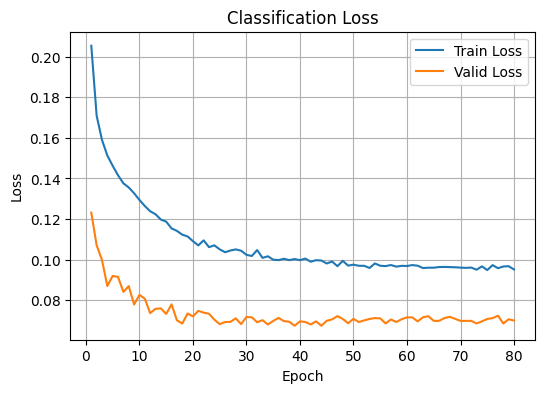

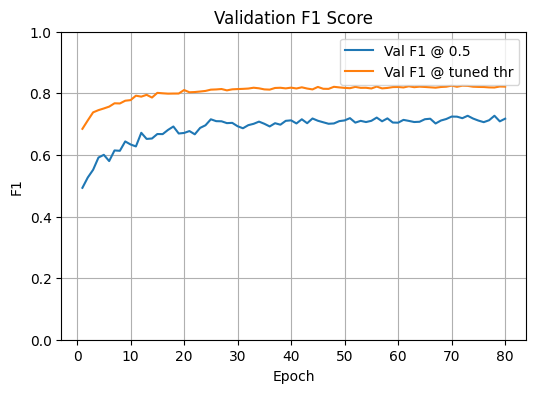

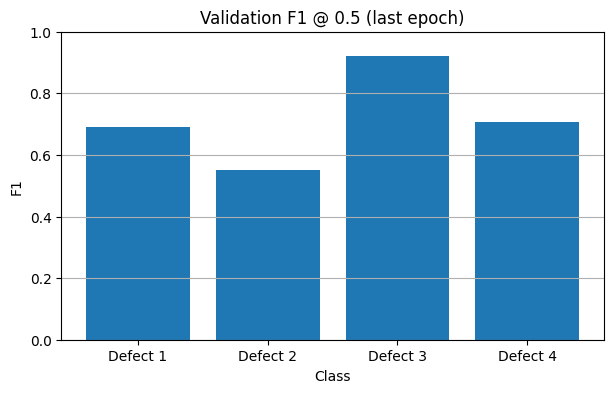

Classifier saved: /kaggle/working/cls_stage2_pred/classifier_best.pth
Thresholds saved: /kaggle/working/cls_stage2_pred/cls_thresholds.npy -> [0.72, 0.81, 0.39, 0.68]


In [33]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

cls_model = build_cls_model(backbone=CLS_BACKBONE, dropout=CLS_DROPOUT)
configure_cls_finetune(cls_model, backbone=CLS_BACKBONE)
cls_model = cls_model.to(device)

criterion = MultiLabelFocalLoss(gamma=CLS_FOCAL_GAMMA, pos_weight=pos_weight)
optimizer = AdamW(
    cls_param_groups(cls_model, backbone=CLS_BACKBONE),
    lr=CLS_LR,
    weight_decay=CLS_WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

cls_scaler = torch.amp.GradScaler(
    cls_amp_device_type(),
    enabled=cls_amp_enabled(),
)
print(f"Classification AMP enabled: {cls_scaler.is_enabled()}")

history, best_thr_from_train = classificator(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=CLS_EPOCHS,
    early_stopping_patience=CLS_EARLY_STOP,
    device=device,
    save_path=str(CLS_CLASSIFIER_CKPT),
    scaler=cls_scaler,
    save_thresholds_path=str(CLS_BEST_THRESHOLDS_PATH),
    eval_use_tta=False,
)

CLS_THRESHOLDS = list(best_thr_from_train)
np.save(CLS_THRESHOLDS_PATH, np.array(CLS_THRESHOLDS, dtype=np.float32))

plot_cls_training_curves(history, out_dir=CLS_OUT_DIR)
class_names = ["Defect 1", "Defect 2", "Defect 3", "Defect 4"]
plot_cls_per_class_f1(history, class_names=class_names, out_dir=CLS_OUT_DIR)
print(f"Classifier saved: {CLS_CLASSIFIER_CKPT}")
print(f"Thresholds saved: {CLS_THRESHOLDS_PATH} -> {CLS_THRESHOLDS}")


## Evaluation

In [34]:
@torch.no_grad()
def collect_cls_predictions(model, loader, device, thr=0.5, use_tta=True):
    model.eval()
    if isinstance(thr, (float, int)):
        thr_t = torch.tensor([float(thr)] * 4, dtype=torch.float32).view(1, -1)
    else:
        thr_t = torch.tensor(list(thr), dtype=torch.float32).view(1, -1)
    probs_all, preds_all, y_all, paths_all = [], [], [], []
    for imgs, y, paths in loader:
        imgs = imgs.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)
        probs = _cls_forward_probs(model, imgs, device)
        if use_tta:
            probs_flip = _cls_forward_probs(model, torch.flip(imgs, dims=[-1]), device)
            probs = (probs + probs_flip) * 0.5
        probs = probs.cpu()
        preds = (probs > thr_t).float()
        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(y.cpu())
        paths_all.extend(paths)
    return (
        torch.cat(probs_all, dim=0),
        torch.cat(preds_all, dim=0),
        torch.cat(y_all, dim=0),
        paths_all,
    )


In [35]:
cls_model.load_state_dict(
    torch.load(CLS_CLASSIFIER_CKPT, map_location=device, weights_only=True)
)
cls_model.eval()

if CLS_BEST_THRESHOLDS_PATH.exists():
    CLS_THRESHOLDS = np.load(CLS_BEST_THRESHOLDS_PATH).tolist()
    print("Loaded thresholds from training:", [round(t, 2) for t in CLS_THRESHOLDS])

probs, preds, labels, paths = collect_cls_predictions(
    model=cls_model,
    loader=val_cls_loader,
    device=device,
    thr=CLS_THRESHOLDS,
    use_tta=True,
)

best_thr, f1_each, macro_f1 = tune_cls_thresholds(probs, labels)
CLS_THRESHOLDS = best_thr
np.save(CLS_THRESHOLDS_PATH, np.array(CLS_THRESHOLDS, dtype=np.float32))

print("Tuned thresholds (TTA val):", [round(t, 2) for t in CLS_THRESHOLDS])
print("F1 per class @ tuned thr:", [round(x, 4) for x in f1_each])
print("Macro F1 @ tuned thr:", round(macro_f1, 4))
print("Saved:", CLS_THRESHOLDS_PATH)

_, tuned_preds, _, _ = collect_cls_predictions(
    model=cls_model,
    loader=val_cls_loader,
    device=device,
    thr=CLS_THRESHOLDS,
    use_tta=True,
)


Loaded thresholds from training: [0.72, 0.81, 0.39, 0.68]
Tuned thresholds (TTA val): [0.72, 0.78, 0.39, 0.68]
F1 per class @ tuned thr: [0.7972, 0.7093, 0.9428, 0.8602]
Macro F1 @ tuned thr: 0.8274
Saved: /kaggle/working/cls_stage2_pred/cls_thresholds.npy


In [36]:
def plot_cls_probability_bars(probs, labels, idx, class_names=None):
    prob = probs[idx].numpy()
    gt = labels[idx].numpy()

    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(prob))]

    x = np.arange(len(class_names))

    plt.figure(figsize=(7, 4))
    plt.bar(x, prob)
    plt.xticks(x, class_names)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title(f"Prediction Probabilities | GT = {gt.astype(int).tolist()}")
    plt.grid(True, axis="y")
    plt.show()

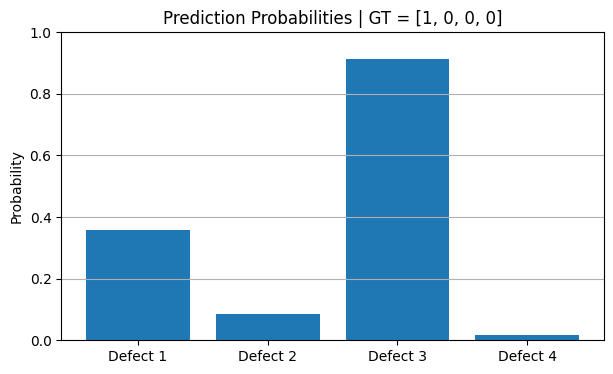

In [37]:
plot_cls_probability_bars( probs=probs, labels=labels, idx=0, class_names=class_names)

In [38]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

@torch.no_grad()
def visualize_cls_predictions(
    model,
    dataset,
    device,
    k=6,
    thr=0.5,
    class_names=None
):
    model.eval()

    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(4)]

    idxs = np.random.choice(
        len(dataset),
        size=min(k, len(dataset)),
        replace=False
    )

    for idx in idxs:
        img, y, path = dataset[idx]

        x = img.unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        preds = (probs > thr).astype(np.int32)

        y_np = y.numpy().astype(np.int32)

        # Vì ảnh đã Normalize nên cần unnormalize để hiển thị
        img_np = img.permute(1, 2, 0).cpu().numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)

        gt_labels = [
            class_names[i]
            for i in range(len(class_names))
            if y_np[i] == 1
        ]

        pred_labels = [
            f"{class_names[i]}({probs[i]:.2f})"
            for i in range(len(class_names))
            if preds[i] == 1
        ]

        if len(gt_labels) == 0:
            gt_text = "None"
        else:
            gt_text = ", ".join(gt_labels)

        if len(pred_labels) == 0:
            pred_text = "None"
        else:
            pred_text = ", ".join(pred_labels)

        plt.figure(figsize=(6, 5))
        plt.imshow(img_np)
        plt.axis("off")
        plt.title(
            f"GT: {gt_text}\nPred: {pred_text}",
            fontsize=10
        )
        plt.show()

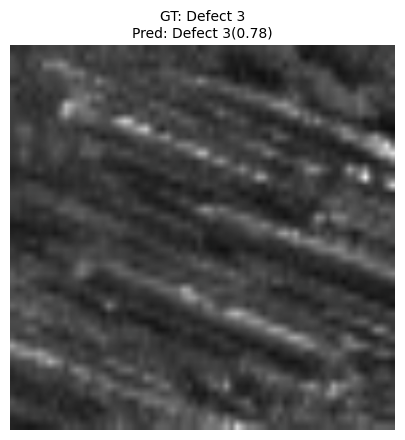

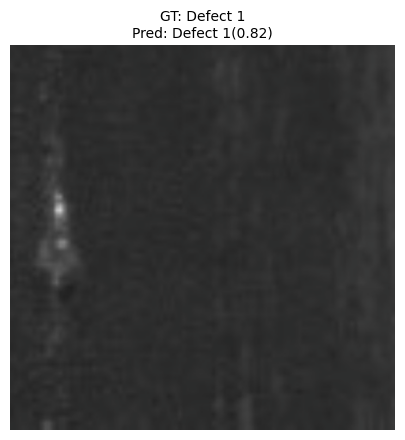

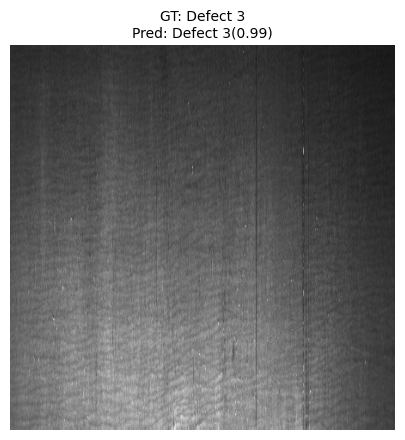

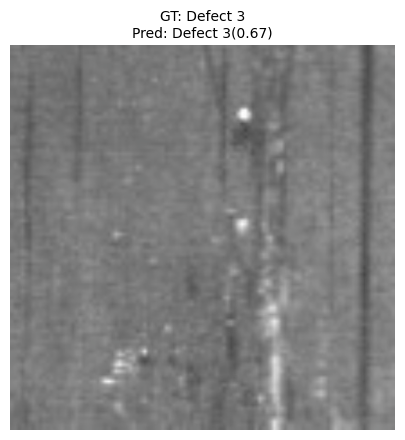

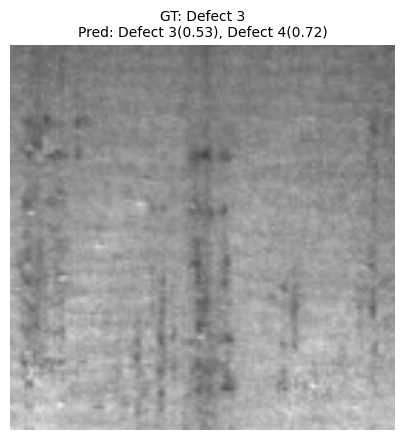

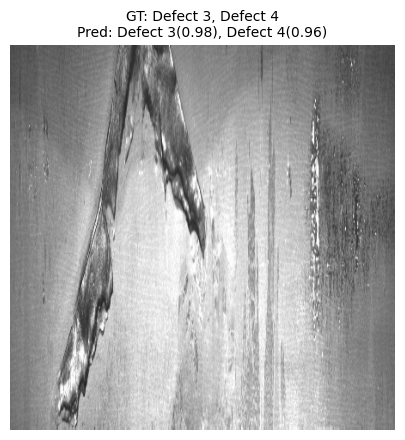

In [39]:
visualize_cls_predictions(
    model=cls_model,
    dataset=val_cls_dataset,
    device=device,
    k=6,
    thr=CLS_THRESHOLDS,
    class_names=class_names,
)
